In [19]:
from typing import Annotated

from langchain_openai import ChatOpenAI
from langchain_core.messages import AnyMessage, AIMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage
from langchain_openrouter import ChatOpenRouter

In [20]:
load_dotenv()

True

In [21]:
llm = ChatOpenRouter(
    model="z-ai/glm-5.3-flash",
    temperature=0.7
)


In [22]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [23]:
def chat_node(state: ChatState):

    decision = interrupt({
        "type": "approval",
        "reason": "Model is about to answer a user question.",
        "question": state["messages"][-1].content,
        "instruction": "Approve this question? yes/no"
    })
    
    if decision["approved"] == 'no':
        return {"messages": [AIMessage(content="Not approved.")]}

    else:
        response = llm.invoke(state["messages"])
        return {"messages": [response]}



In [24]:
# 3. Build the graph: START -> chat -> END
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)

builder.add_edge(START, "chat")
builder.add_edge("chat", END)

# Checkpointer is required for interrupts
checkpointer = MemorySaver()

# Compile the app
app = builder.compile(checkpointer=checkpointer)

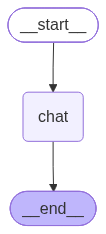

In [25]:
app

In [26]:
# Create a new thread id for this conversation
config = {"configurable": {"thread_id": '1234'}}

# ---- STEP 1: user asks a question ----
initial_input = {
    "messages": [
        ("user", "Explain gradient descent in very simple terms.")
    ]
}

# Invoke the graph for the first time
result = app.invoke(initial_input, config=config)


In [27]:
result

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='84b71903-be4f-48c5-bc08-7b6553ef7192')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a user question.', 'question': 'Explain gradient descent in very simple terms.', 'instruction': 'Approve this question? yes/no'}, id='e5bf4f37c07b2365ef3104fda36e00af')]}

In [28]:
message = result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a user question.',
 'question': 'Explain gradient descent in very simple terms.',
 'instruction': 'Approve this question? yes/no'}

In [29]:
user_input = input(f"\nBackend message - {message} \n Approve this question? (y/n): ")


In [30]:
# Resume the graph with the approval decision
final_result = app.invoke(
    Command(resume={"approved": user_input}),
    config=config,
)

In [31]:
print(final_result["messages"][-1].content)

# Gradient Descent, Explained Simply

Imagine you're standing on a hillside in thick fog, trying to reach the lowest point of the valley. You can't see anything, but you *can* feel the slope under your feet.

So you do the obvious thing: figure out which direction is downhill, take a step that way, stop, feel the slope again, and take another step. Repeat this enough times, and you'll eventually work your way down to the bottom.

**That's gradient descent.**

Now here's how it maps to machine learning:

- **The valley** = the model's error (how wrong its predictions are)
- **Feeling the slope** = checking which direction would increase or decrease the error (this is the "gradient")
- **Taking a step** = slightly adjusting the model's internal settings
- **Repeating** = doing this thousands of times until the error is as small as possible

**One tricky detail: step size.** If your steps are too big, you might leap right over the bottom of the valley and end up on the other side. Too sma